In [1]:
pip install pandas matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

url = "https://api.slingacademy.com/v1/sample-data/files/student-scores.csv"
df = pd.read_csv(url)


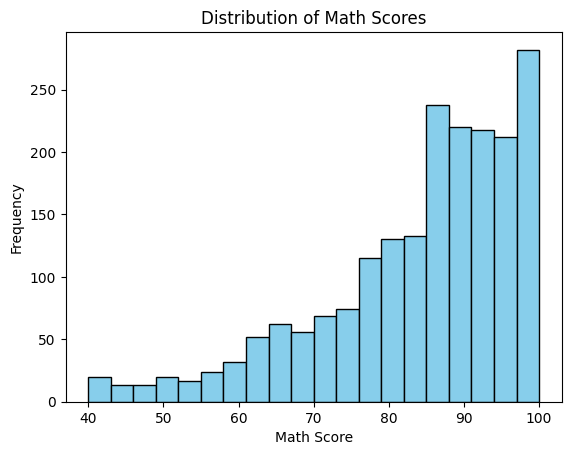

In [3]:
import matplotlib.pyplot as plt

plt.hist(df['math_score'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.show()


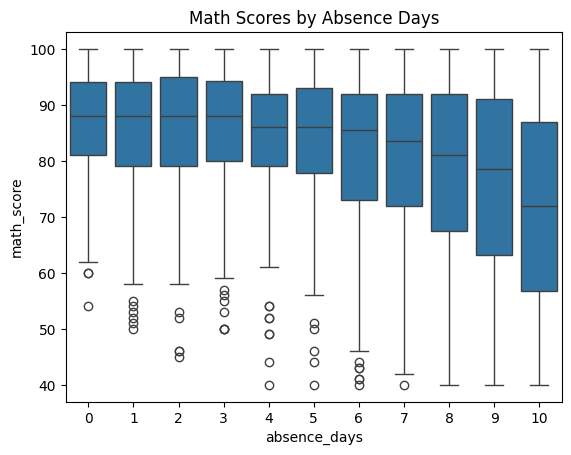

In [4]:
import seaborn as sns

sns.boxplot(x='absence_days', y='math_score', data=df)
plt.title('Math Scores by Absence Days')
plt.show()


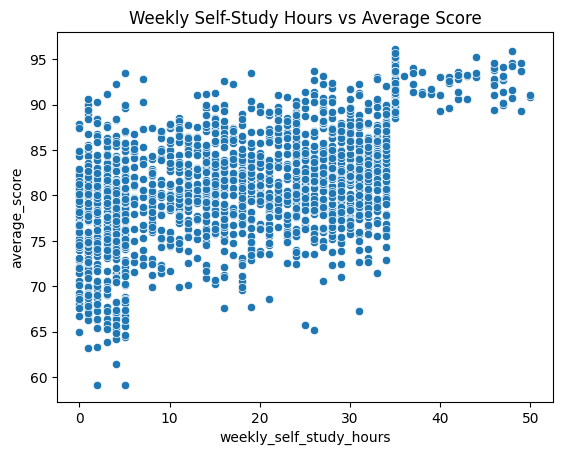

In [5]:
df['average_score'] = df[['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']].mean(axis=1)

sns.scatterplot(x='weekly_self_study_hours', y='average_score', data=df)
plt.title('Weekly Self-Study Hours vs Average Score')
plt.show()


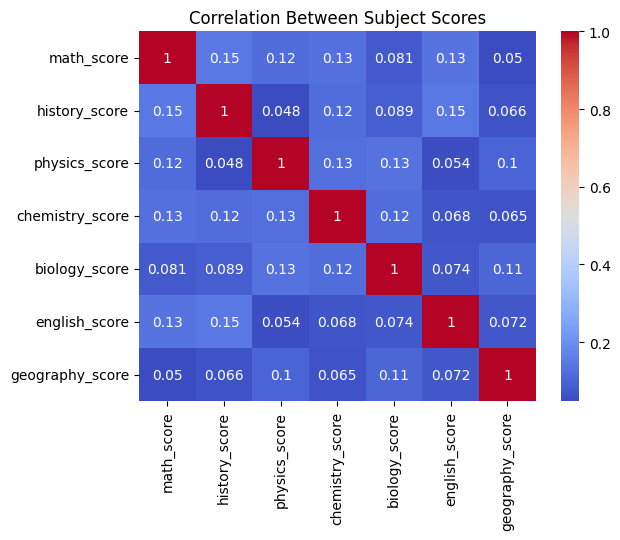

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Between Subject Scores')
plt.show()


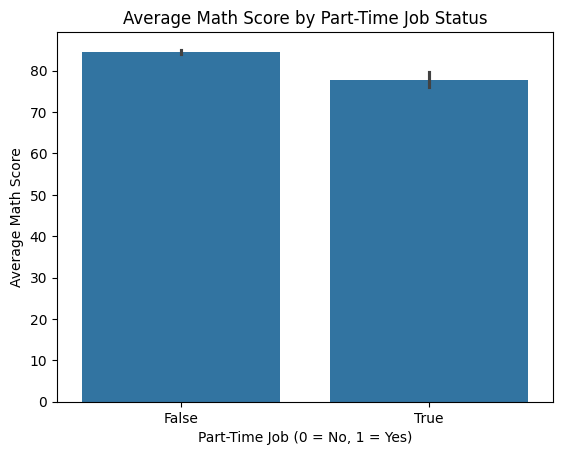

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='part_time_job', y='math_score', data=df)
plt.title('Average Math Score by Part-Time Job Status')
plt.xlabel('Part-Time Job (0 = No, 1 = Yes)')
plt.ylabel('Average Math Score')
plt.show()


In [9]:
participation_counts = df['extracurricular_activities'].value_counts().sort_index()

In [10]:
labels = ['No', 'Yes']
colors = ['lightcoral', 'skyblue']

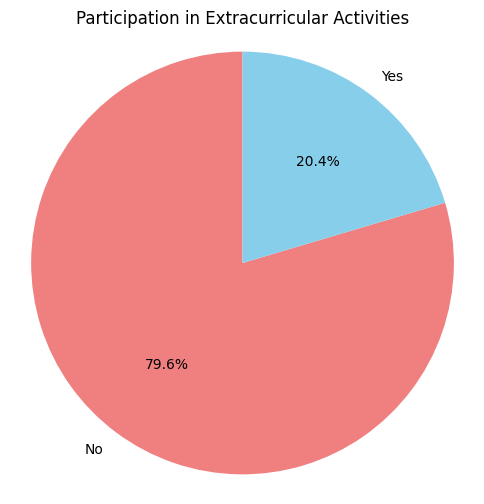

In [11]:
plt.figure(figsize=(6, 6))
plt.pie(participation_counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Participation in Extracurricular Activities')
plt.axis('equal')  # Makes the pie chart circular
plt.show()

In [12]:
subject_averages = df[['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']].mean()

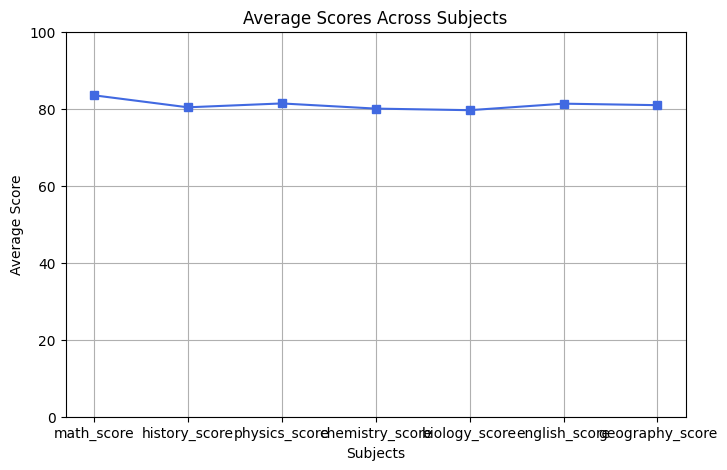

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(subject_averages.index, subject_averages.values, marker='s', linestyle='-', color='royalblue')
plt.title('Average Scores Across Subjects')
plt.xlabel('Subjects')
plt.ylabel('Average Score')
plt.ylim(0, 100)
plt.grid(True)
plt.show()

In [14]:
student_scores = df.loc[0, ['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']]

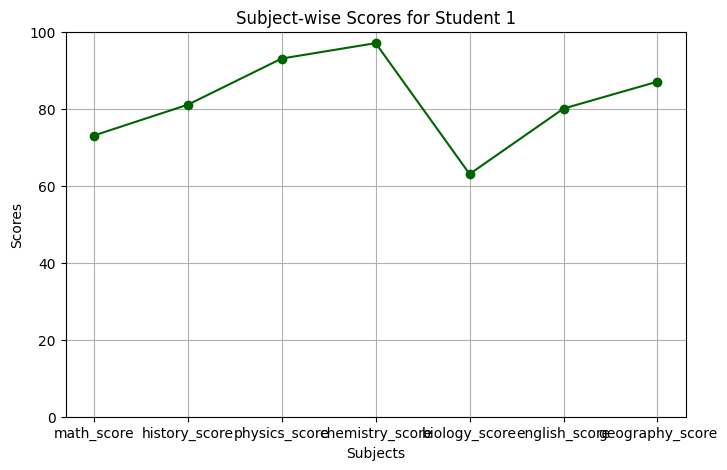

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(student_scores.index, student_scores.values, marker='o', linestyle='-', color='darkgreen')
plt.title('Subject-wise Scores for Student 1')
plt.xlabel('Subjects')
plt.ylabel('Scores')
plt.ylim(0, 100)
plt.grid(True)
plt.show()

Descriptive Statistics Summary

In [16]:
df.describe()

,id,absence_days,weekly_self_study_hours,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score,average_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,3.665500,17.755500,83.452000,80.332000,81.336500,79.995000,79.58150,81.277500,80.888000,80.980357
std,577.494589,2.629271,12.129604,13.224906,12.736046,12.539453,12.777895,13.72219,12.027087,11.637705,6.042224
min,1.000000,0.000000,0.000000,40.000000,50.000000,50.000000,50.000000,30.00000,50.000000,60.000000,59.142857
25%,500.750000,2.000000,5.000000,77.000000,69.750000,71.000000,69.000000,69.00000,72.000000,71.000000,77.285714
50%,1000.500000,3.000000,18.000000,87.000000,82.000000,83.000000,81.000000,81.00000,83.000000,81.000000,81.000000
75%,1500.250000,5.000000,28.000000,93.000000,91.000000,92.000000,91.000000,91.00000,91.000000,91.000000,84.714286
max,2000.000000,10.000000,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,99.000000,100.000000,96.142857


Inferential Statistical Tests:
ANOVA Test

In [17]:
import scipy.stats as stats

group1 = df[df['extracurricular_activities'] == 0]['math_score']
group2 = df[df['extracurricular_activities'] == 1]['math_score']
f_stat, p_value = stats.f_oneway(group1, group2)


Linear Regression (Math Score vs. Weekly Study Hours)

In [18]:
import statsmodels.api as sm

X = df['weekly_self_study_hours']
y = df['math_score']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             math_score   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     366.2
Date:                Mon, 16 Jun 2025   Prob (F-statistic):           4.35e-75
Time:                        21:13:02   Log-Likelihood:                -7833.3
No. Observations:                2000   AIC:                         1.567e+04
Df Residuals:                    1998   BIC:                         1.568e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

Diagnostics

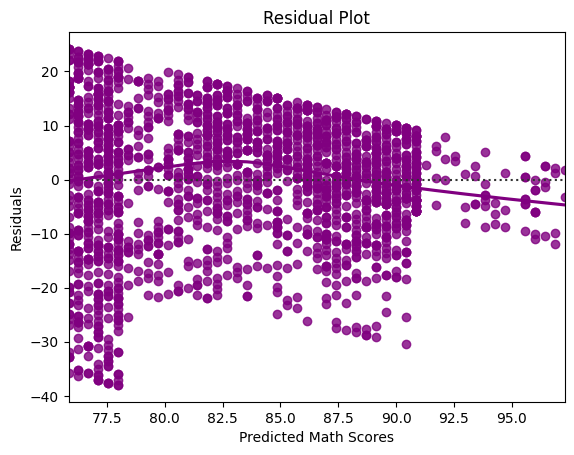

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

predictions = model.predict(X)
residuals = y - predictions

sns.residplot(x=predictions, y=residuals, lowess=True, color="purple")
plt.title('Residual Plot')
plt.xlabel('Predicted Math Scores')
plt.ylabel('Residuals')
plt.show()


Final Linear Regression Model: Weekly Study Hours → Math Score

In [20]:
import statsmodels.api as sm

X = df['weekly_self_study_hours']
y = df['math_score']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             math_score   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     366.2
Date:                Mon, 16 Jun 2025   Prob (F-statistic):           4.35e-75
Time:                        21:18:09   Log-Likelihood:                -7833.3
No. Observations:                2000   AIC:                         1.567e+04
Df Residuals:                    1998   BIC:                         1.568e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

ANOVA: Effect of Extracurricular Participation on Math Score

In [21]:
from scipy import stats

group_no = df[df['extracurricular_activities'] == 0]['math_score']
group_yes = df[df['extracurricular_activities'] == 1]['math_score']

f_stat, p_val = stats.f_oneway(group_no, group_yes)
print(f"F-Statistic: {f_stat}, p-value: {p_val}")


F-Statistic: 5.621381529355204, p-value: 0.017837035501934374


Logistic Regression (Binary Classification: High vs Low Performer)

In [22]:
df['high_performer'] = (df['average_score'] > 70).astype(int)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df[['weekly_self_study_hours', 'absence_days']]
y = df['high_performer']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
model = LogisticRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)


Accuracy: 0.9616666666666667
